# **Dataset Exploration**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

In [3]:
# Load the dataset
df = pd.read_csv('loan_data.csv')

In [4]:
# Show the first few rows of the dataset
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
# Show the last few rows of the dataset
df.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,debt_consolidation,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


In [6]:
# Show basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [7]:
# Show descriptive statistics of the dataset
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [8]:
# Define the shape of the dataset
df.shape

(9578, 14)

In [19]:
# Show the column names
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

In [9]:
# Check for unique values
df.nunique()

,0
credit.policy,2
purpose,7
int.rate,249
installment,4788
log.annual.inc,1987
dti,2529
fico,44
days.with.cr.line,2687
revol.bal,7869
revol.util,1035


In [10]:
# Check for missing values
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [11]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

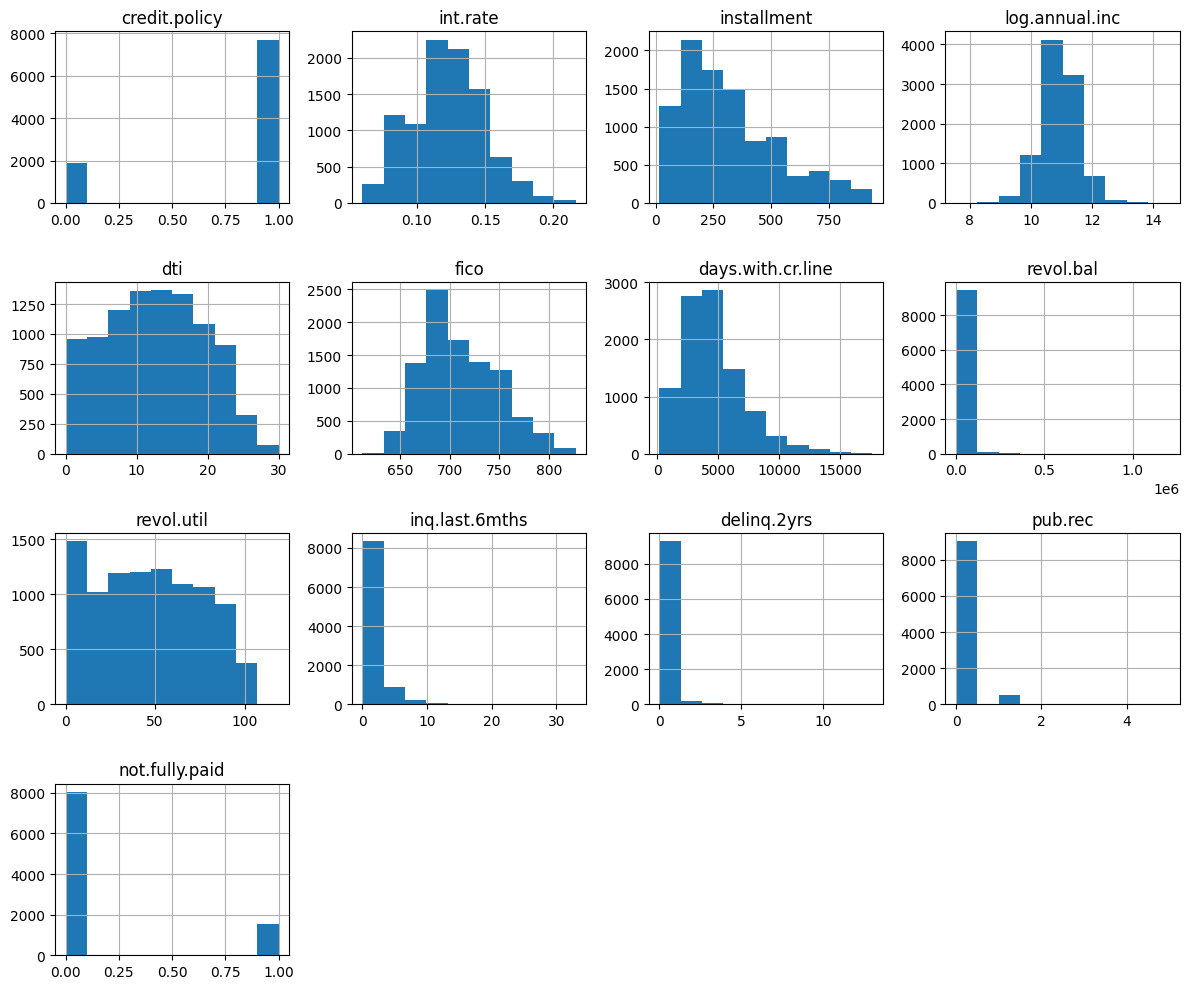

In [12]:
# Explore numerical values
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

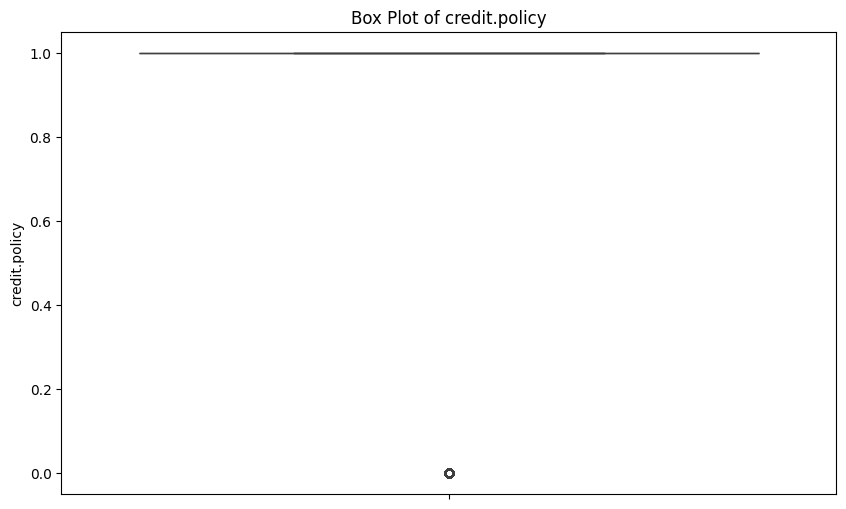

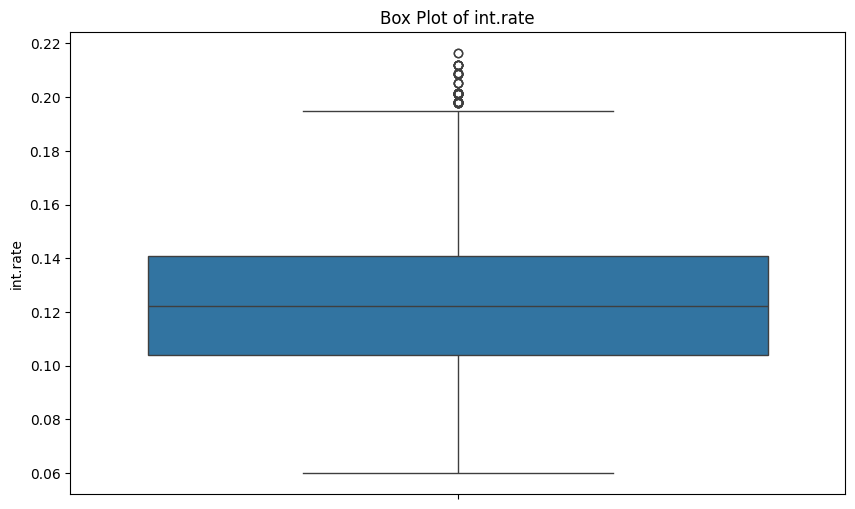

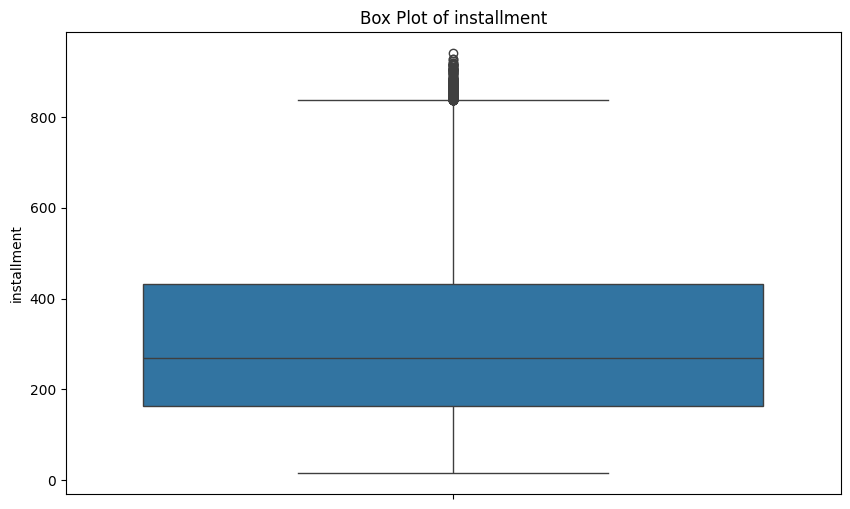

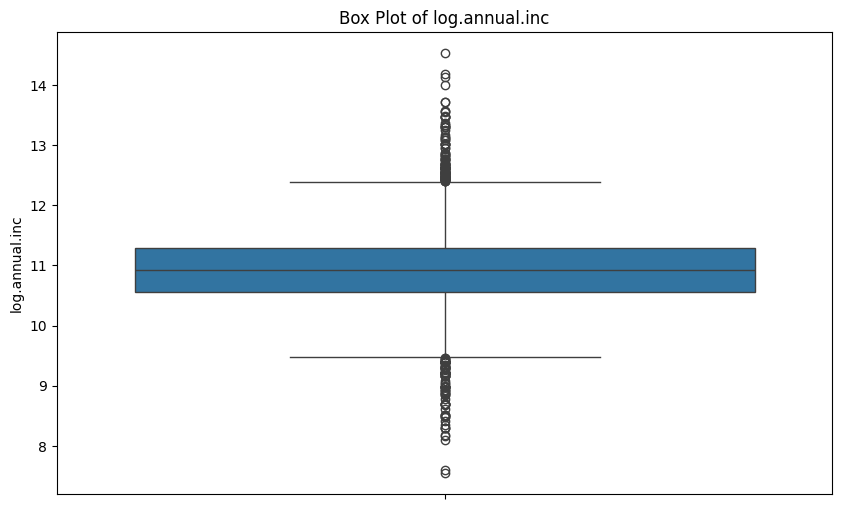

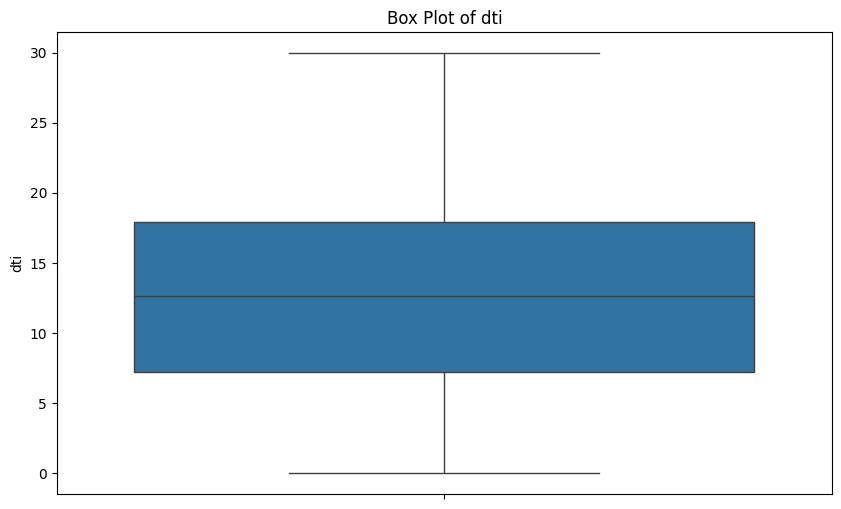

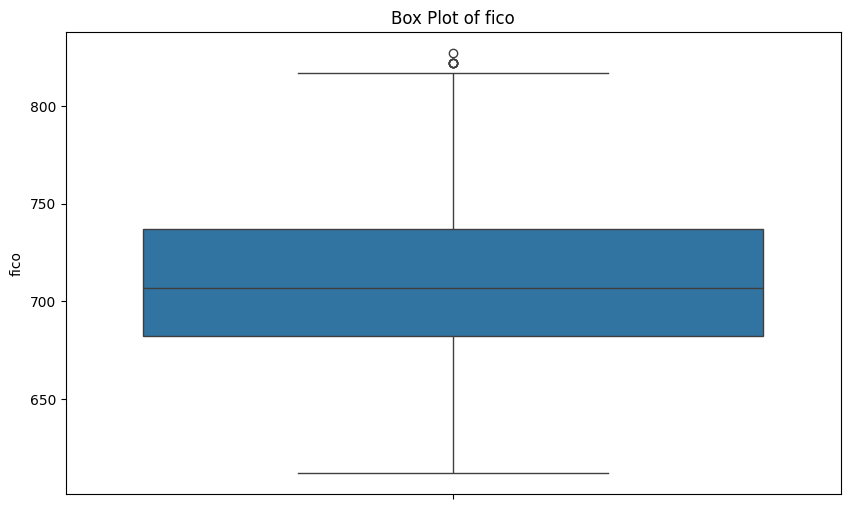

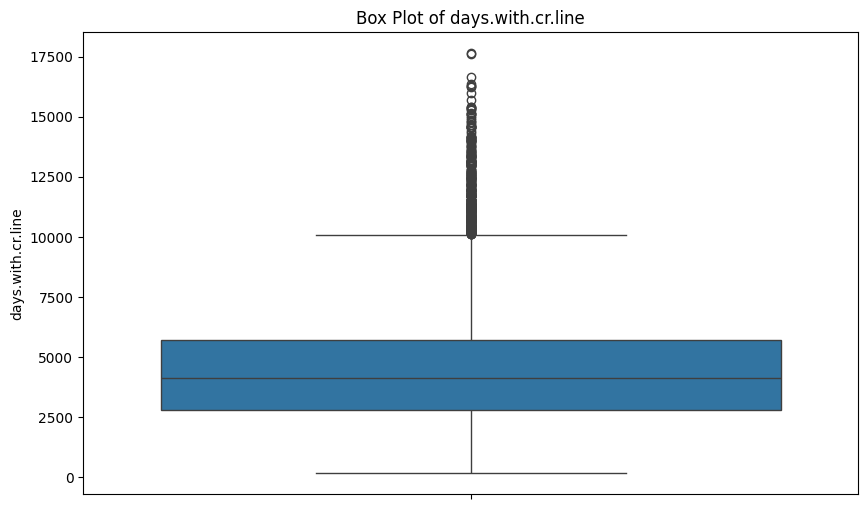

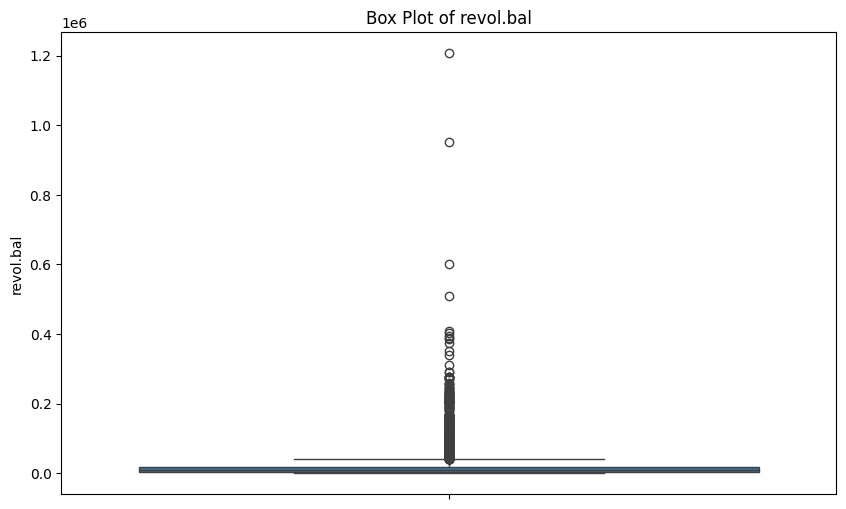

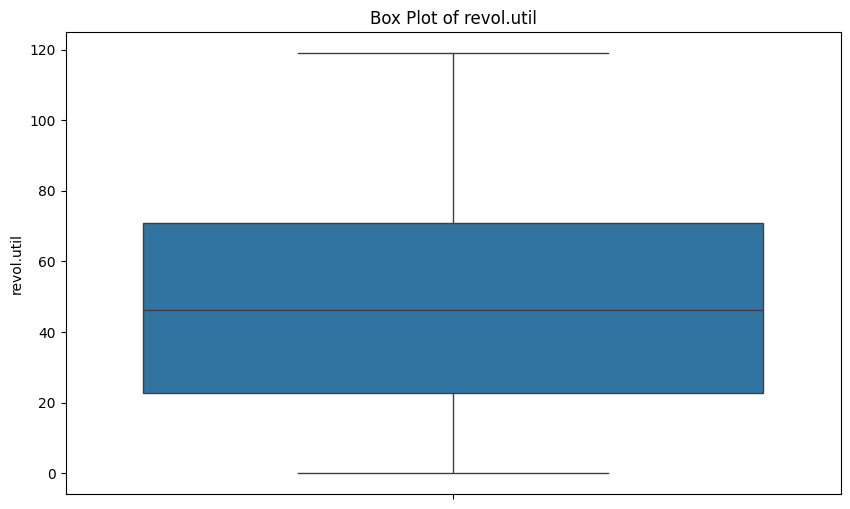

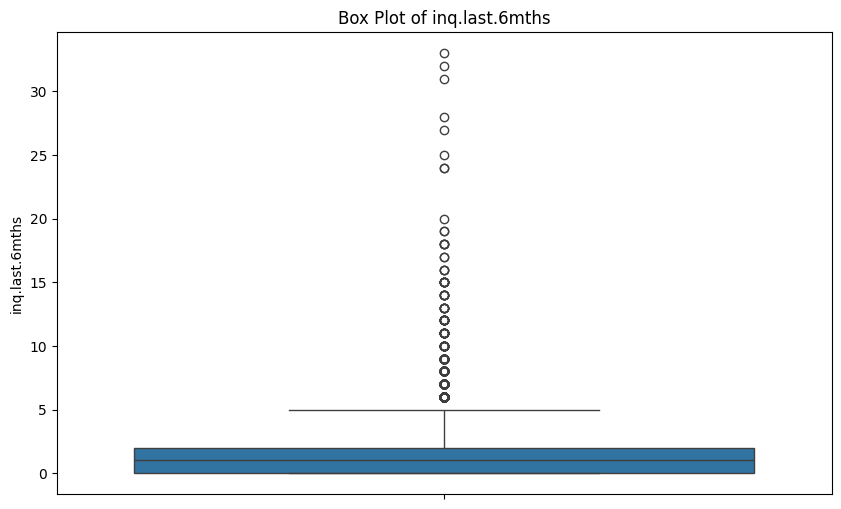

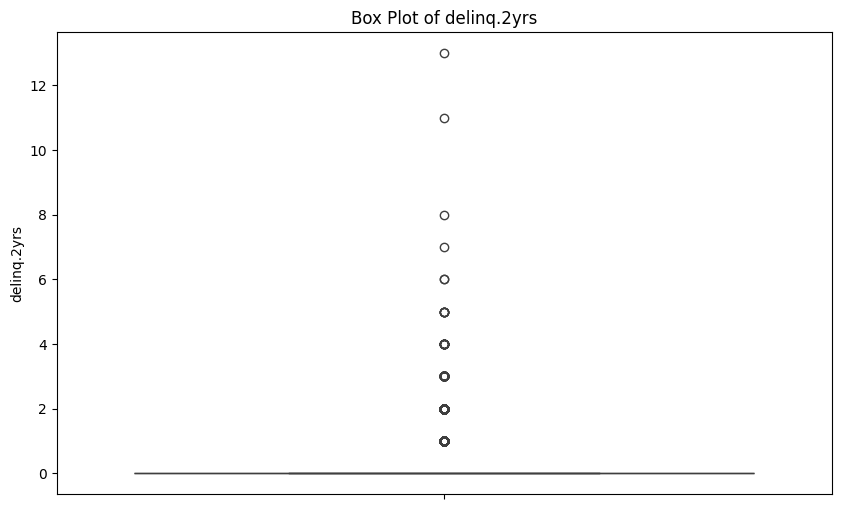

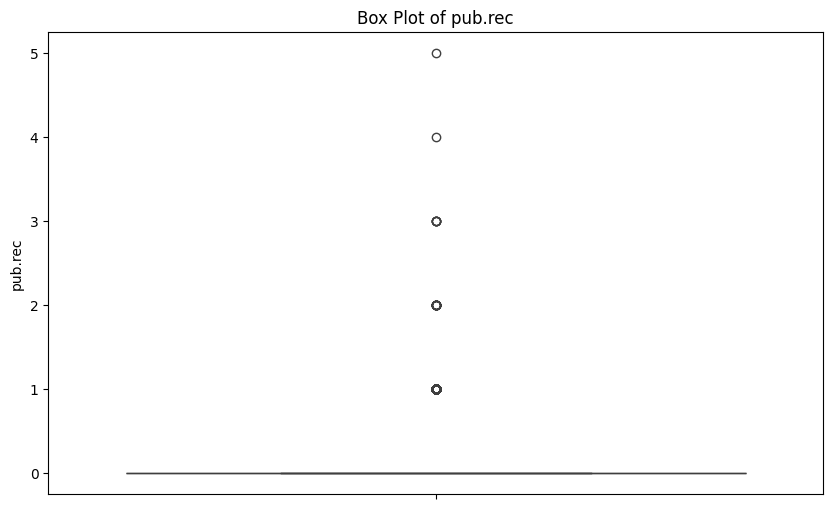

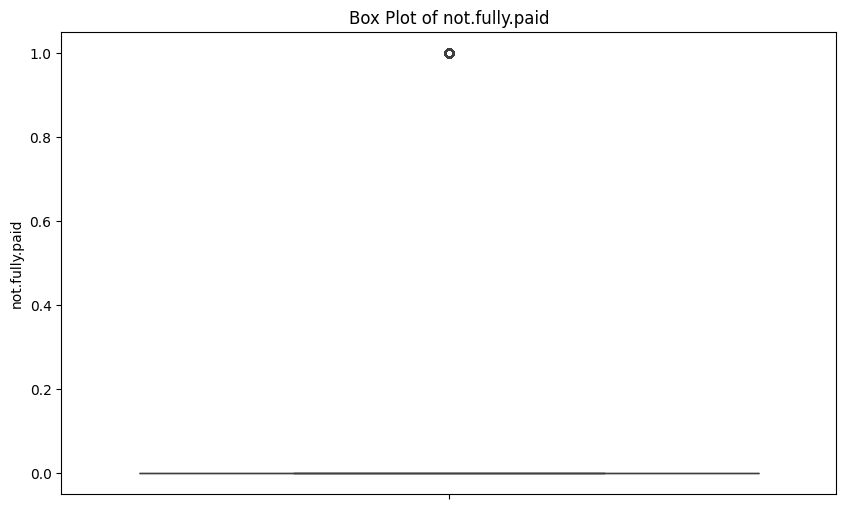

In [20]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, y=col)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

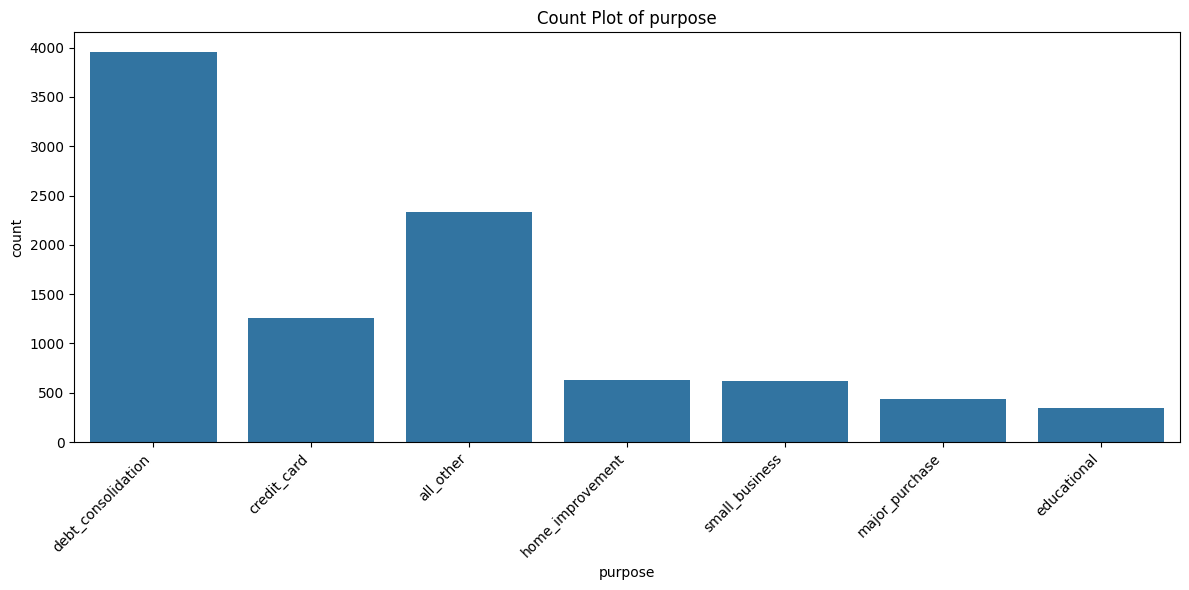

In [23]:
# Explore categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

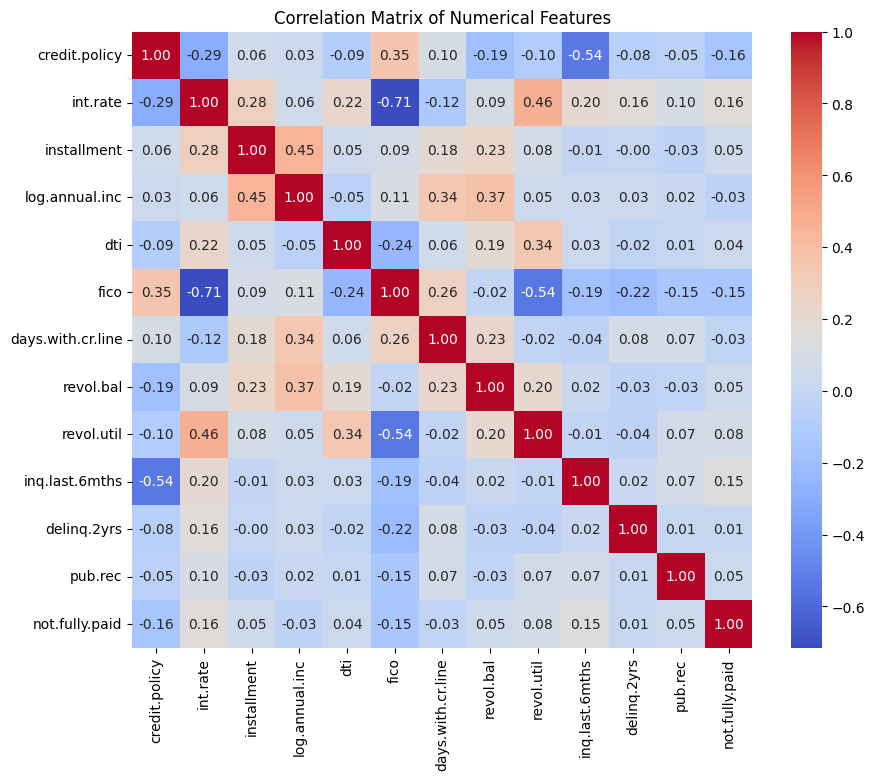

In [25]:
# Analyze the relationship between the features
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features') # Updated title for clarity
plt.show()

<Figure size 2000x1700 with 0 Axes>

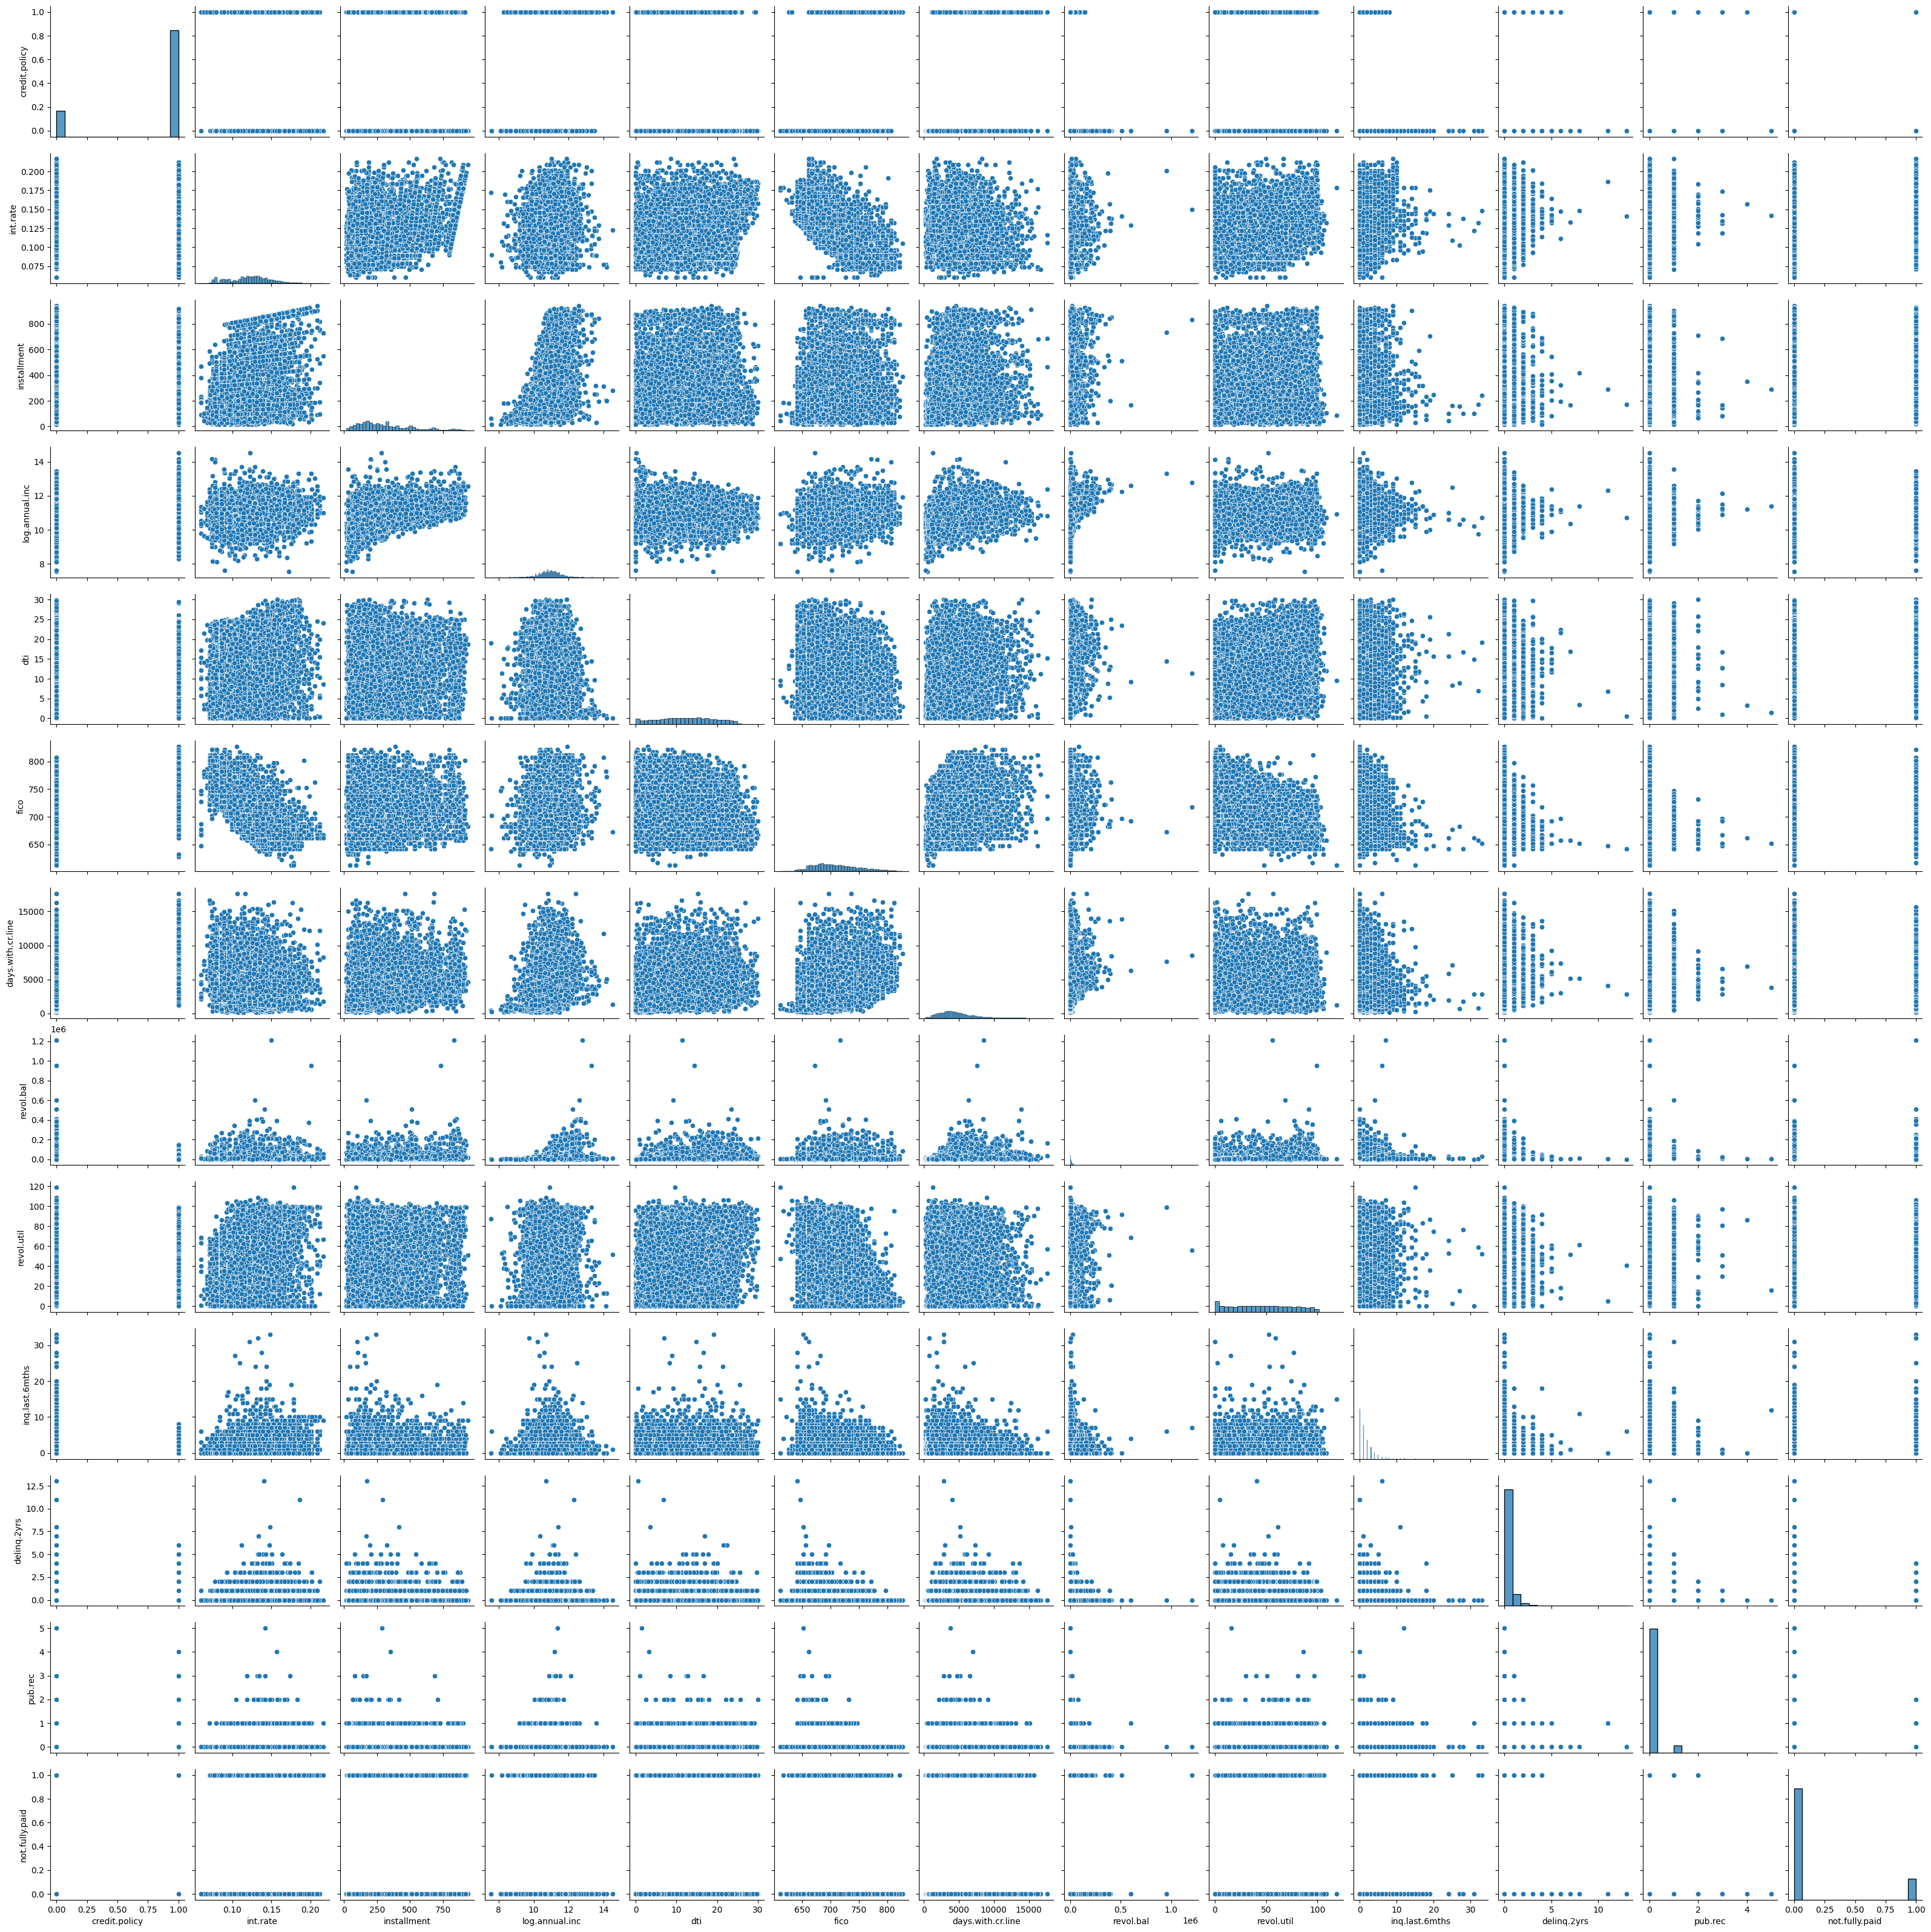

In [27]:
plt.figure(figsize=(20, 17))
sns.pairplot(df)
plt.show()

# **Model Training And Evaluation**

In [28]:
# Encode categorical variables
df_processed = df.copy()
le = LabelEncoder()
df_processed['purpose_encoded'] = le.fit_transform(df_processed['purpose'])
df_processed = df_processed.drop('purpose', axis=1)

In [29]:
# Separate features and target
X = df_processed.drop('not.fully.paid', axis=1)
y = df_processed['not.fully.paid']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [31]:
# Train LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train_balanced, y_train_balanced)
lgb_pred = lgb_model.predict(X_test)

# Train SVM model
svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_balanced, y_train_balanced)
svm_pred = svm_model.predict(X_test)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
rf_pred = rf_model.predict(X_test)

In [32]:
# Evaluate LightGBM
lgb_precision = precision_score(y_test, lgb_pred)
lgb_recall = recall_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred)
lgb_report = classification_report(y_test, lgb_pred)
lgb_cm = confusion_matrix(y_test, lgb_pred)

# Evaluate SVM
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
svm_report = classification_report(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

# Evaluate Random Forest
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

In [33]:
# Print results
print("LOAN DEFAULT PREDICTION MODEL PERFORMANCE REPORT")
print("=" * 60)

print("\nLightGBM Results:")
print(f"Precision: {lgb_precision:.4f}")
print(f"Recall: {lgb_recall:.4f}")
print(f"F1-Score: {lgb_f1:.4f}")
print("\nClassification Report:")
print(lgb_report)
print("\nConfusion Matrix:")
print(lgb_cm)
print("-" * 40)

print("\nSVM Results:")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print("\nClassification Report:")
print(svm_report)
print("\nConfusion Matrix:")
print(svm_cm)
print("-" * 40)

print("\nRandom Forest Results:")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print("\nClassification Report:")
print(rf_report)
print("\nConfusion Matrix:")
print(rf_cm)
print("-" * 40)

LOAN DEFAULT PREDICTION MODEL PERFORMANCE REPORT

LightGBM Results:
Precision: 0.2819
Recall: 0.2085
F1-Score: 0.2397

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1609
           1       0.28      0.21      0.24       307

    accuracy                           0.79      1916
   macro avg       0.57      0.55      0.56      1916
weighted avg       0.76      0.79      0.77      1916


Confusion Matrix:
[[1446  163]
 [ 243   64]]
----------------------------------------

SVM Results:
Precision: 0.1709
Recall: 0.1759
F1-Score: 0.1734

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1609
           1       0.17      0.18      0.17       307

    accuracy                           0.73      1916
   macro avg       0.51      0.51      0.51      1916
weighted avg       0.73      0.73      0.73      1916


Confusion Matrix:
[[1347  26

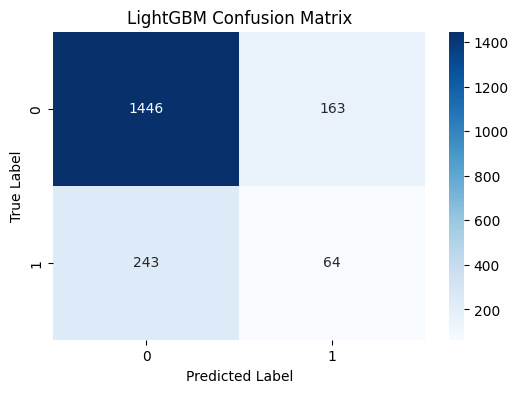

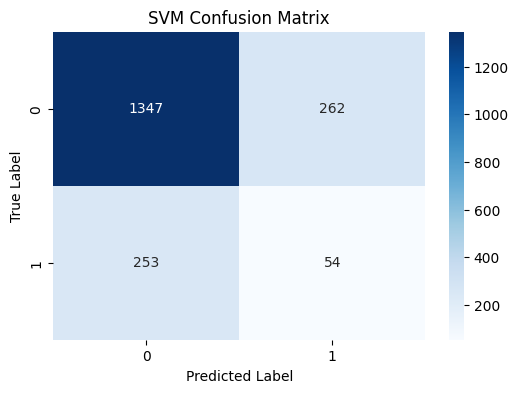

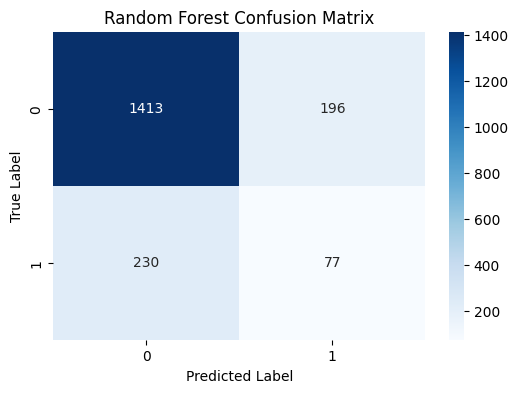

In [34]:
# Plot Confusion Matrix for LightGBM
plt.figure(figsize=(6, 4))
sns.heatmap(lgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot Confusion Matrix for SVM
plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# **Recommendations For Lenders**

# -> Use the model with highest recall to minimize missed defaults

# -> Consider precision-recall tradeoff based on business costs

# -> Regularly retrain models with new data

# -> Implement risk-based pricing strategies

# -> Should be used as a tool to complement and enhance existing credit assessment processes